# Задача 5.11г)

Ищем аппроксимацию в виде $y = a + bx$

$$
E(a,b) = \int_0^\pi (\sin x - a - bx)^2 dx
$$

Из условий $\frac{\partial E}{\partial a} = 0$ и $\frac{\partial E}{\partial b} = 0$:

$$
\begin{cases}
\int_0^\pi [\sin x - a - bx] \cdot 1 dx = 0 \\
\int_0^\pi [\sin x - a - bx] \cdot x dx = 0
\end{cases}
$$

$$
\int_0^\pi 1 dx = \pi, \quad
\int_0^\pi x dx = \frac{\pi^2}{2}, \quad
\int_0^\pi x^2 dx = \frac{\pi^3}{3}
$$
$$
\int_0^\pi \sin x dx = 2, \quad
\int_0^\pi x \sin x dx = \pi
$$

$$
\begin{cases}
2 - a\pi - b\frac{\pi^2}{2} = 0 \\
\pi - a\frac{\pi^2}{2} - b\frac{\pi^3}{3} = 0
\end{cases}
$$

$$
\begin{cases}
\pi a + \frac{\pi^2}{2}b = 2 \\
\frac{\pi}{2}a + \frac{\pi^2}{3}b = 1
\end{cases}
$$

$$
\frac{\pi}{2}a + \frac{\pi^2}{3}b = 1
$$

$$
\frac{\pi}{2}a + \frac{\pi^2}{4}b = 1
$$

$$
\left(\frac{\pi^2}{3} - \frac{\pi^2}{4}\right)b = 0 \Rightarrow \frac{\pi^2}{12}b = 0 \Rightarrow b = 0
$$

$$
\pi a = 2 \Rightarrow a = \frac{2}{\pi}
$$

Наилучшая линейная аппроксимация:
$$
y = \frac{2}{\pi}
$$


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-4154164079.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, f_original, 'b-', linewidth=2, label='$f(x) = \sin(x)$')
/tmp/ipython-input-4154164079.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x, f_approx, 'r--', linewidth=2, label='Аппроксимация $y = \\frac{2}{\pi}$')
/tmp/ipython-input-4154164079.py:15: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Сравнение функции $\\sin(x)$ и её наилучшей линейной аппроксимации на $[0, \pi]$')


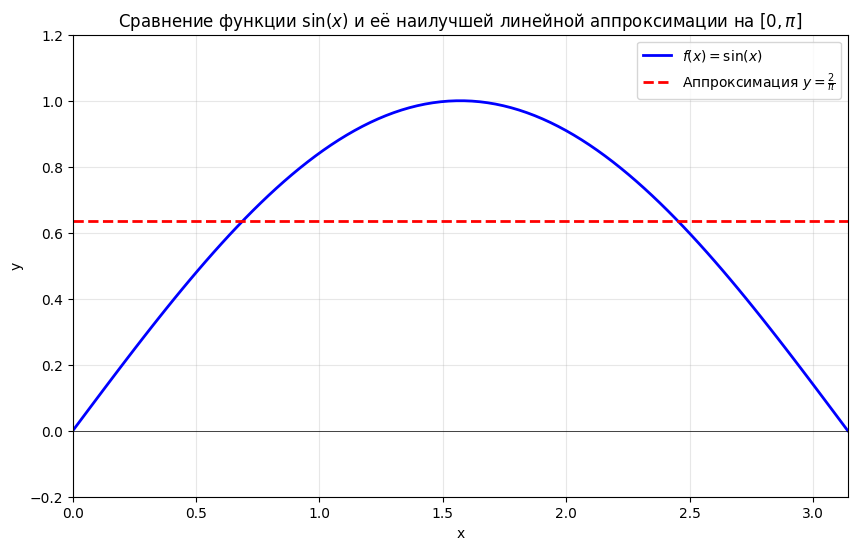

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, np.pi, 100)
f_original = np.sin(x)
f_approx = 2/np.pi * np.ones_like(x)

plt.figure(figsize=(10, 6))
plt.plot(x, f_original, 'b-', linewidth=2, label='$f(x) = \sin(x)$')
plt.plot(x, f_approx, 'r--', linewidth=2, label='Аппроксимация $y = \\frac{2}{\pi}$')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение функции $\\sin(x)$ и её наилучшей линейной аппроксимации на $[0, \pi]$')
plt.legend()
plt.xlim(0, np.pi)
plt.ylim(-0.2, 1.2)
plt.show()

# Задача 5.12а)г)

=== базис x^n ===
N=2: Предсказание 2010 = 312470336, Ошибка = 3724798
N=3: Предсказание 2010 = 309020979, Ошибка = 275441
N=4: Предсказание 2010 = 305706175, Ошибка = 3039363
N=5: Предсказание 2010 = 340607866, Ошибка = 31862328


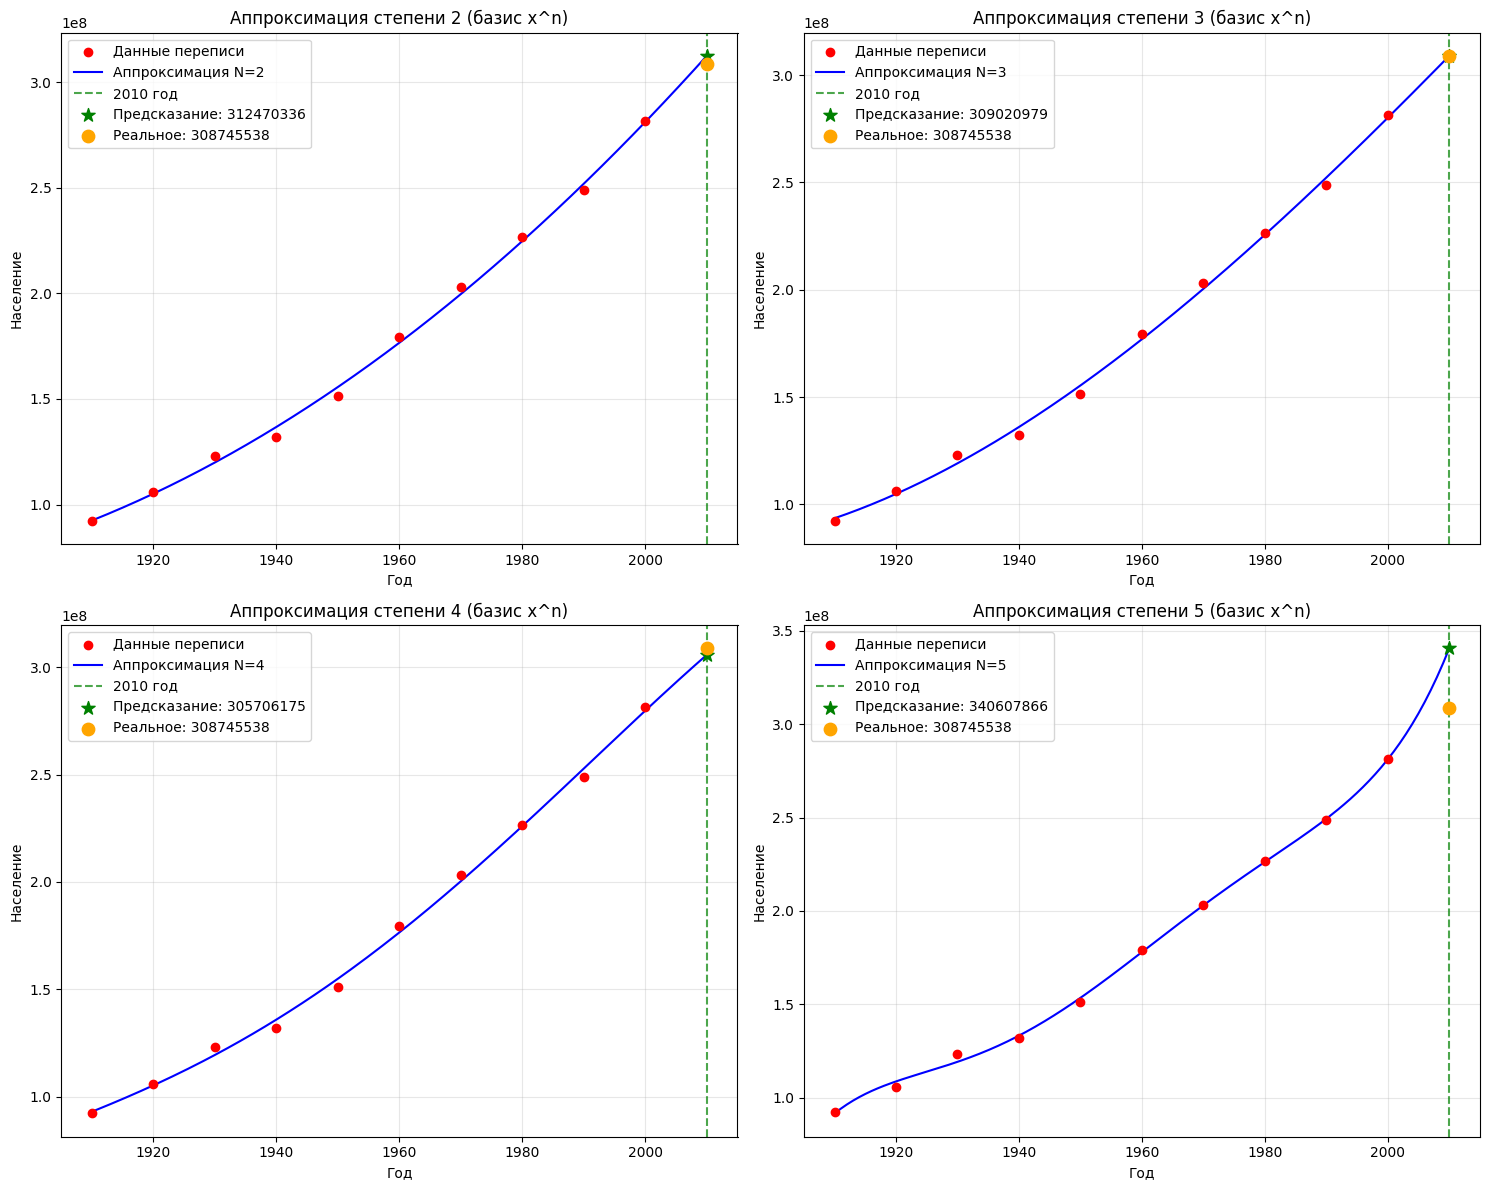


=== базис ((x-1955)/45)^n ===
N=2: Предсказание 2010 = 312470336, Ошибка = 3724798
N=3: Предсказание 2010 = 309020979, Ошибка = 275441
N=4: Предсказание 2010 = 305706176, Ошибка = 3039362
N=5: Предсказание 2010 = 340607732, Ошибка = 31862194


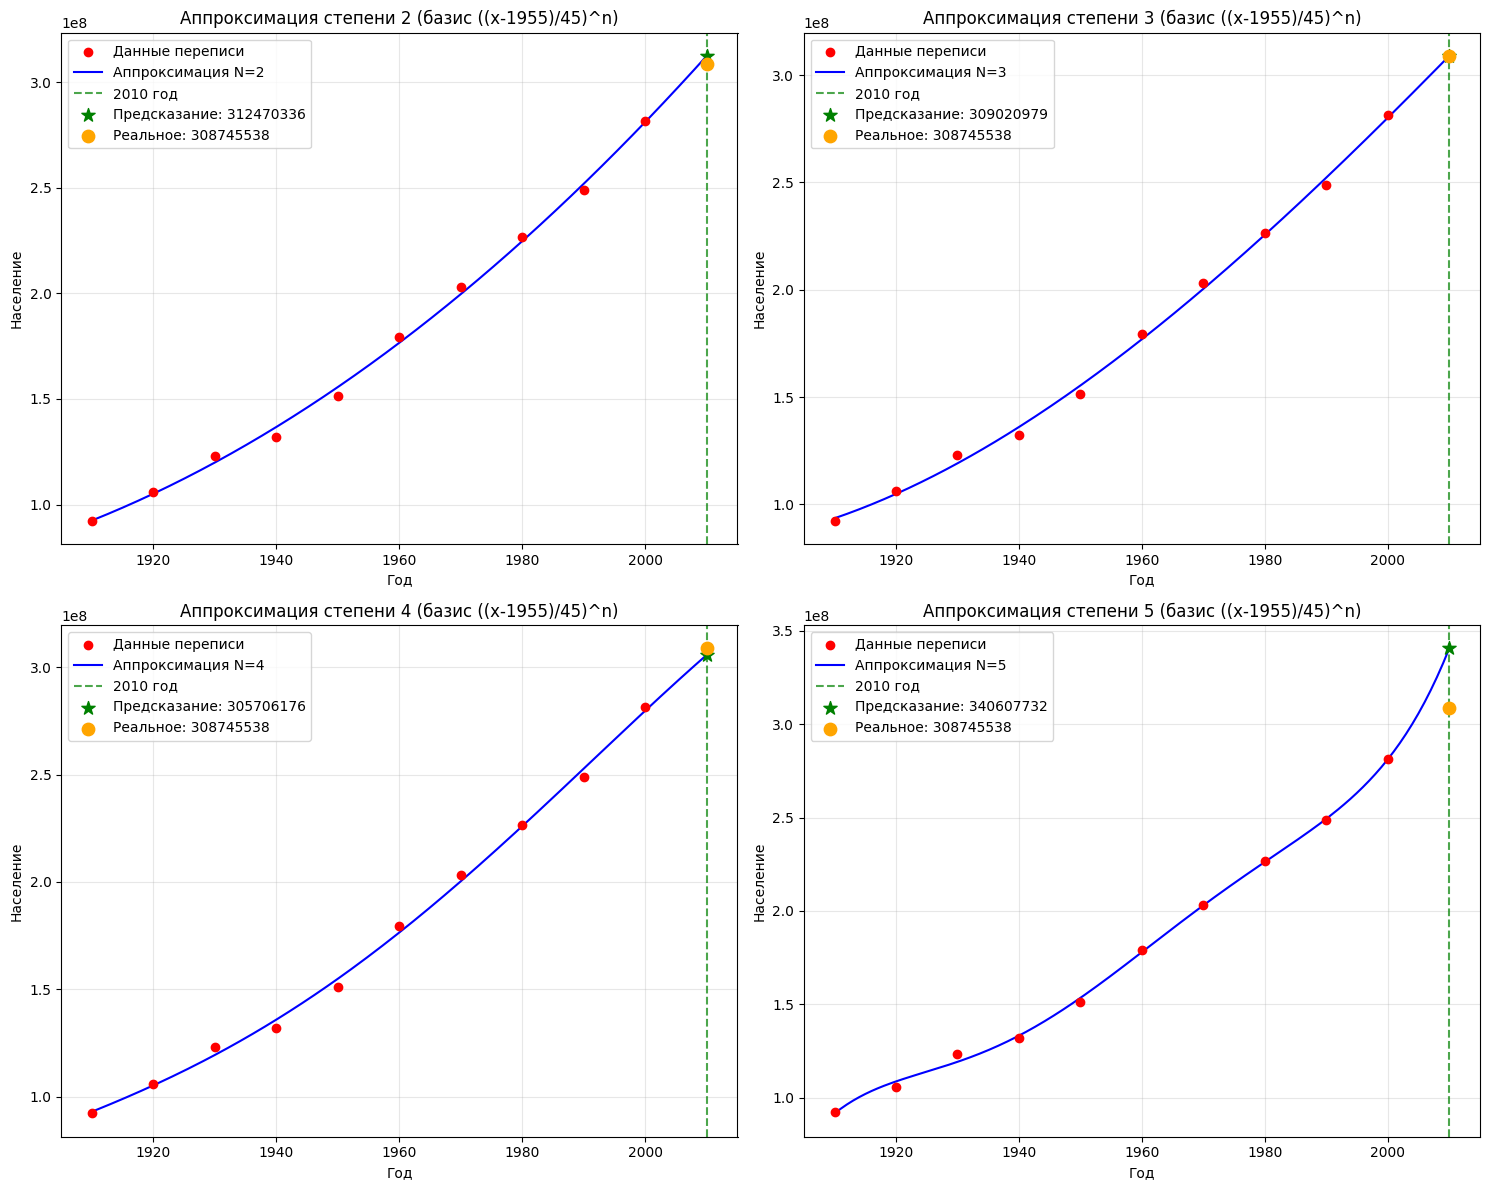

Сравнение
Степень | Базис x^n | Базис ((x-1955)/45)^n
--------------------------------------------------
     2 |   3724798 |                 3724798
     3 |    275441 |                  275441
     4 |   3039363 |                 3039362
     5 |  31862328 |                31862194


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyfit, polyval

years = np.array([1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000])
population = np.array([92228496, 106021537, 123202624, 132164569, 151325798,
                      179323175, 203211926, 226545805, 248709873, 281421906])

exact_2010 = 308745538

degrees = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

print("=== базис x^n ===")
for i, N in enumerate(degrees):
    coeffs = polyfit(years, population, N)

    years_extended = np.linspace(1910, 2010, 200)
    pop_fit = polyval(years_extended, coeffs)

    pred_2010 = polyval(2010, coeffs)
    error = abs(pred_2010 - exact_2010)

    print(f"N={N}: Предсказание 2010 = {pred_2010:.0f}, Ошибка = {error:.0f}")

    axes[i].scatter(years, population, color='red', label='Данные переписи', zorder=5)
    axes[i].plot(years_extended, pop_fit, 'b-', label=f'Аппроксимация N={N}')
    axes[i].axvline(2010, color='green', linestyle='--', alpha=0.7, label='2010 год')
    axes[i].scatter(2010, pred_2010, color='green', marker='*', s=100, zorder=6, label=f'Предсказание: {pred_2010:.0f}')
    axes[i].scatter(2010, exact_2010, color='orange', marker='o', s=80, zorder=6, label=f'Реальное: {exact_2010}')
    axes[i].set_xlabel('Год')
    axes[i].set_ylabel('Население')
    axes[i].set_title(f'Аппроксимация степени {N} (базис x^n)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== базис ((x-1955)/45)^n ===")

x_scaled = (years - 1955) / 45

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, N in enumerate(degrees):
    coeffs_scaled = polyfit(x_scaled, population, N)

    years_extended = np.linspace(1910, 2010, 200)
    x_scaled_extended = (years_extended - 1955) / 45
    pop_fit_scaled = polyval(x_scaled_extended, coeffs_scaled)

    x_2010_scaled = (2010 - 1955) / 45
    pred_2010_scaled = polyval(x_2010_scaled, coeffs_scaled)
    error_scaled = abs(pred_2010_scaled - exact_2010)

    print(f"N={N}: Предсказание 2010 = {pred_2010_scaled:.0f}, Ошибка = {error_scaled:.0f}")

    axes[i].scatter(years, population, color='red', label='Данные переписи', zorder=5)
    axes[i].plot(years_extended, pop_fit_scaled, 'b-', label=f'Аппроксимация N={N}')
    axes[i].axvline(2010, color='green', linestyle='--', alpha=0.7, label='2010 год')
    axes[i].scatter(2010, pred_2010_scaled, color='green', marker='*', s=100, zorder=6, label=f'Предсказание: {pred_2010_scaled:.0f}')
    axes[i].scatter(2010, exact_2010, color='orange', marker='o', s=80, zorder=6, label=f'Реальное: {exact_2010}')
    axes[i].set_xlabel('Год')
    axes[i].set_ylabel('Население')
    axes[i].set_title(f'Аппроксимация степени {N} (базис ((x-1955)/45)^n)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Сравнение")
print("Степень | Базис x^n | Базис ((x-1955)/45)^n")
print("-" * 50)
for N in degrees:
    coeffs_a = polyfit(years, population, N)
    pred_a = polyval(2010, coeffs_a)
    error_a = abs(pred_a - exact_2010)

    x_scaled = (years - 1955) / 45
    coeffs_g = polyfit(x_scaled, population, N)
    x_2010_scaled = (2010 - 1955) / 45
    pred_g = polyval(x_2010_scaled, coeffs_g)
    error_g = abs(pred_g - exact_2010)

    print(f"{N:6} | {error_a:9.0f} | {error_g:23.0f}")

В пунтке г) мы центрируем данные и получаем значения в базисе многочлена меньше, это улучшает обусловленность и уменьшает ошибку, что явно видно при пятой степени.

ИСПРАВЛЕНИЕ

=== БАЗИС x^n ===
N=2:
  Прогноз 2010 = 312470336
  Ошибка = 3724798
  MSE = 8.49e+12

N=3:
  Прогноз 2010 = 309020979
  Ошибка = 275441
  MSE = 7.99e+12

N=4:
  Прогноз 2010 = 305706175
  Ошибка = 3039363
  MSE = 7.84e+12

N=5:
  Прогноз 2010 = 340607807
  Ошибка = 31862269
  MSE = 3.19e+12



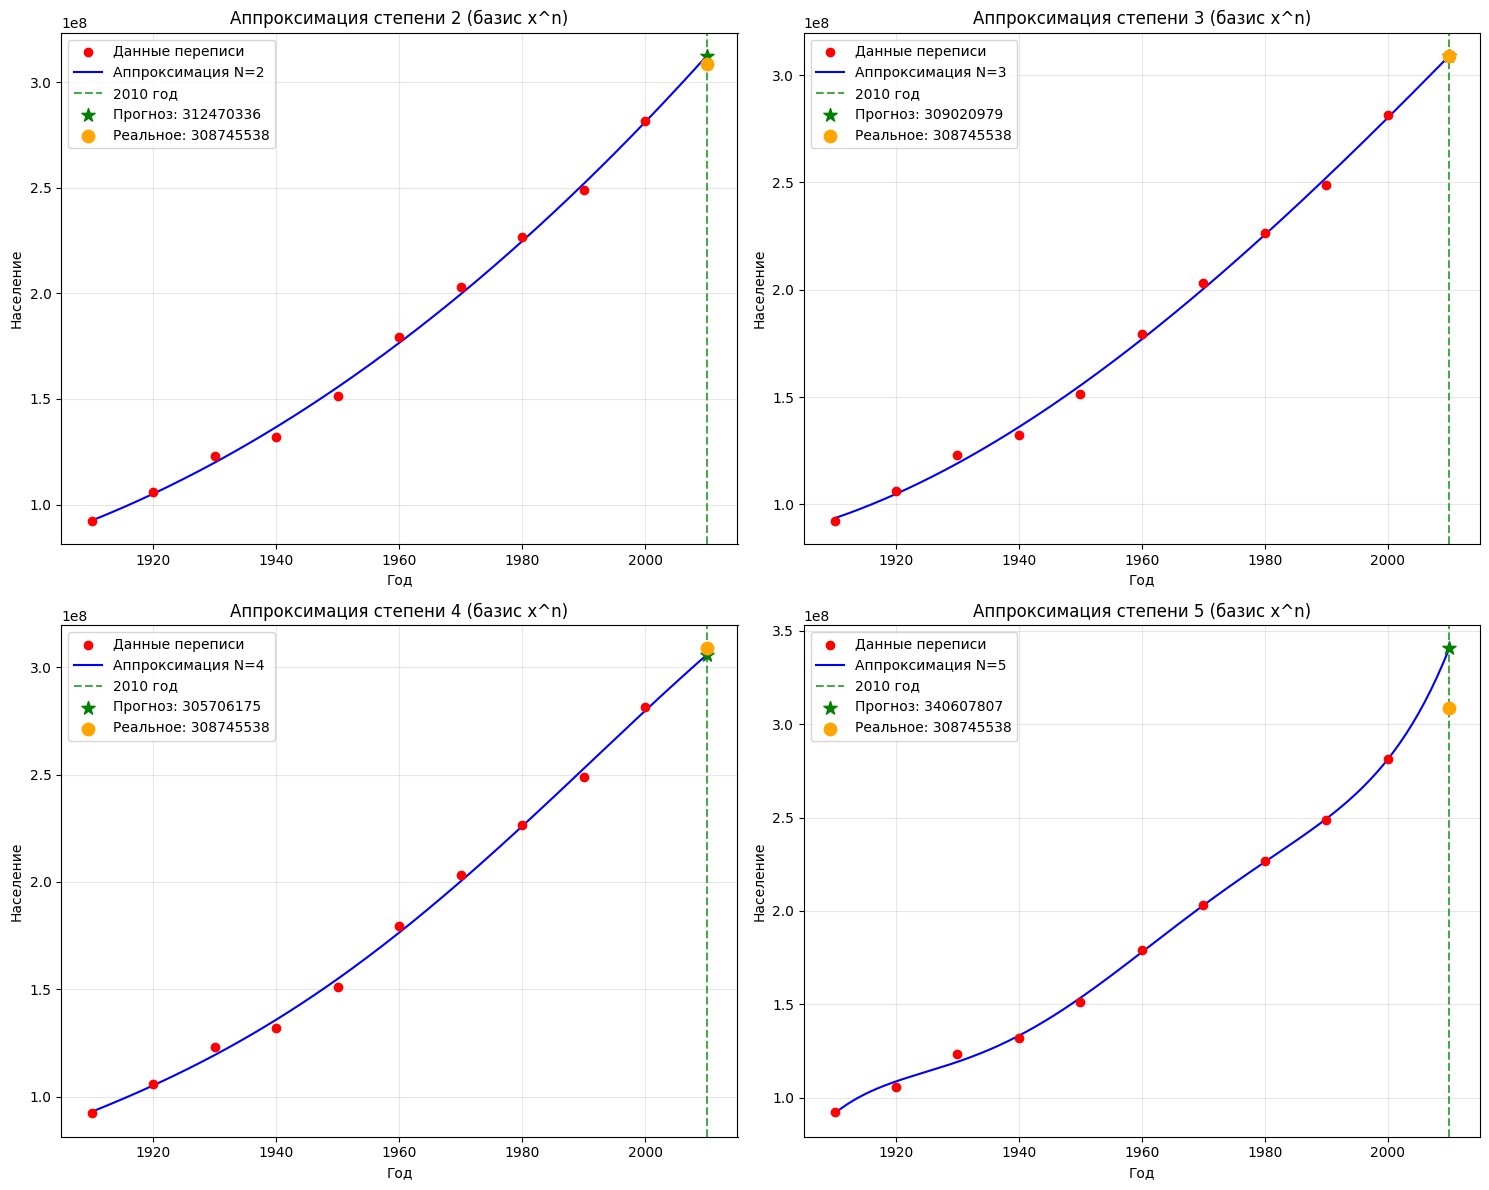


=== БАЗИС ((x-1955)/45)^n ===
N=2:
  Прогноз 2010 = 312470336
  Ошибка = 3724798
  MSE = 8.49e+12

N=3:
  Прогноз 2010 = 309020979
  Ошибка = 275441
  MSE = 7.99e+12

N=4:
  Прогноз 2010 = 305706175
  Ошибка = 3039363
  MSE = 7.84e+12

N=5:
  Прогноз 2010 = 340607732
  Ошибка = 31862194
  MSE = 3.19e+12



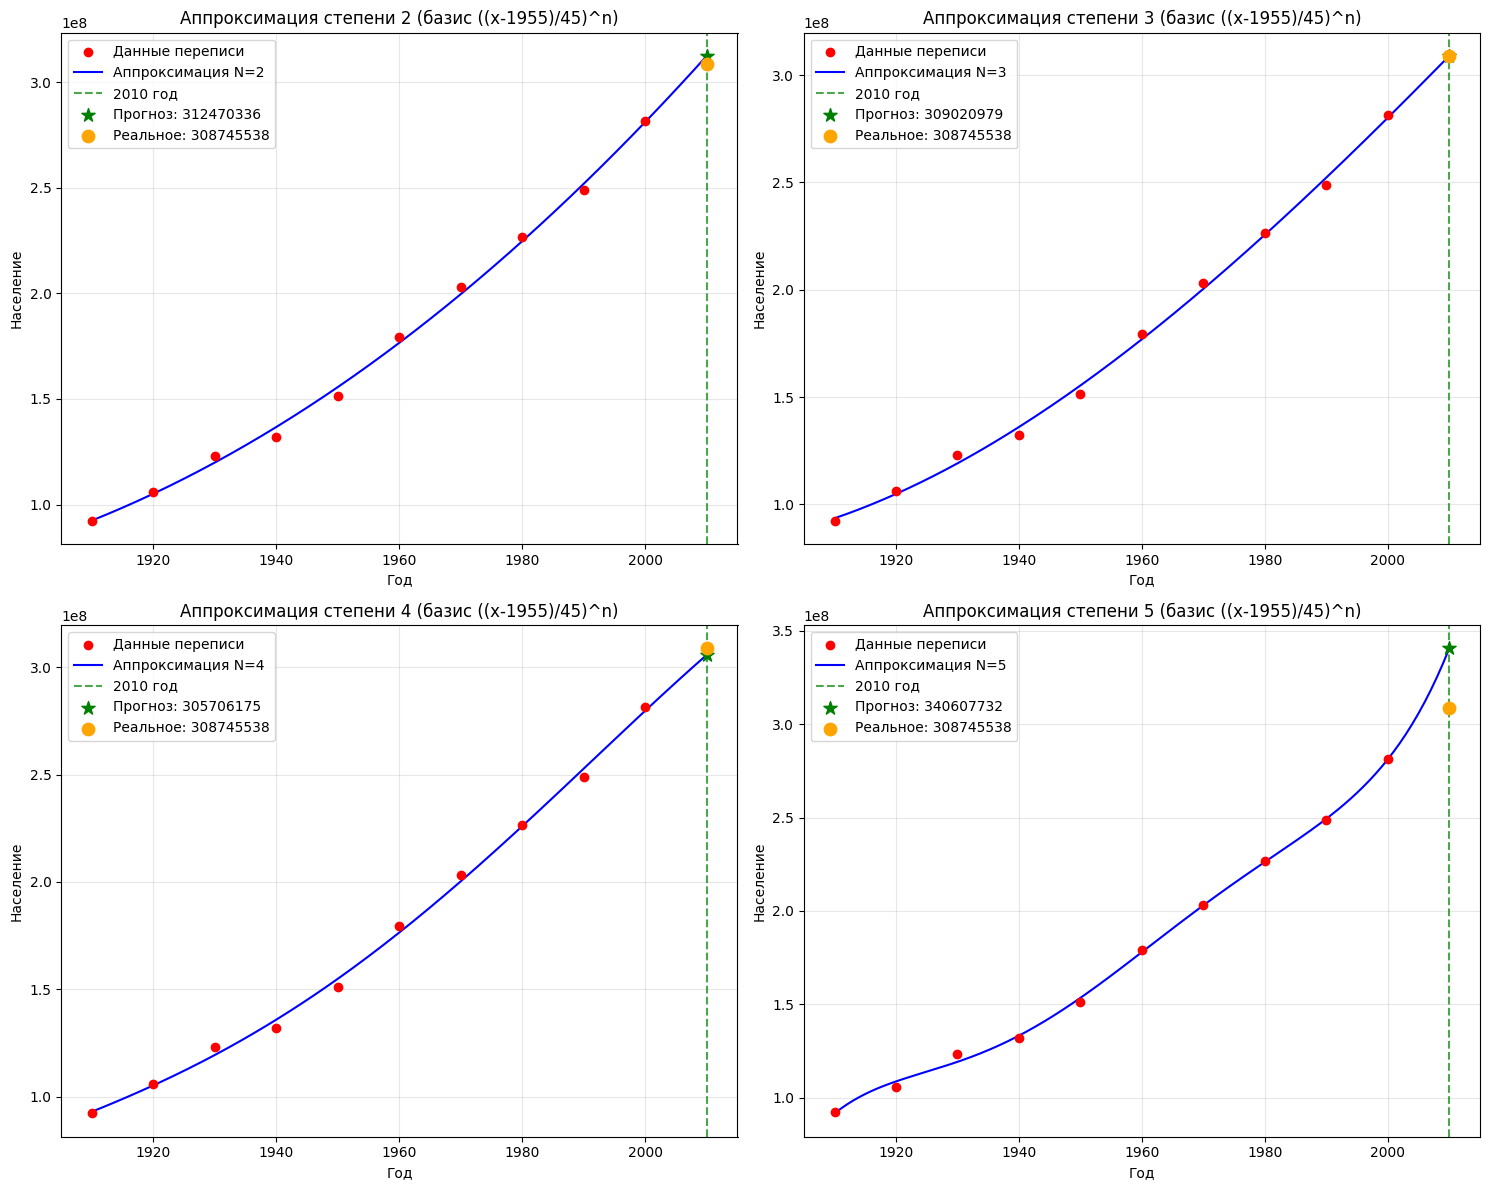


СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Степень    Базис x^n            Базис ((x-1955)/45)^n    
N          Ошибка 2010          Ошибка 2010              
------------------------------------------------------------
2          3724798              3724798                  
3          275441               275441                   
4          3039363              3039363                  
5          31862269             31862194                 


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

years = np.array([1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000],
                 dtype=np.float64)
population = np.array([92228496, 106021537, 123202624, 132164569, 151325798,
                      179323175, 203211926, 226545805, 248709873, 281421906],
                     dtype=np.float64)

exact_2010 = 308745538.0
degrees = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

print("=== БАЗИС x^n ===")
results_a = []

for i, N in enumerate(degrees):
    coeffs = np.polyfit(years, population, N)
    p = np.poly1d(coeffs)

    years_extended = np.linspace(1910, 2010, 200)
    pop_fit = p(years_extended)

    pred_2010 = p(2010.0)
    error = abs(pred_2010 - exact_2010)

    y_fit = p(years)
    mse = np.mean((population - y_fit)**2)

    results_a.append({
        'N': N,
        'pred': pred_2010,
        'error': error,
        'mse': mse
    })

    print(f"N={N}:")
    print(f"  Прогноз 2010 = {pred_2010:.0f}")
    print(f"  Ошибка = {error:.0f}")
    print(f"  MSE = {mse:.2e}")
    print()

    axes[i].scatter(years, population, color='red', label='Данные переписи', zorder=5)
    axes[i].plot(years_extended, pop_fit, 'b-', label=f'Аппроксимация N={N}')
    axes[i].axvline(2010, color='green', linestyle='--', alpha=0.7, label='2010 год')
    axes[i].scatter(2010, pred_2010, color='green', marker='*', s=100, zorder=6,
                   label=f'Прогноз: {pred_2010:.0f}')
    axes[i].scatter(2010, exact_2010, color='orange', marker='o', s=80, zorder=6,
                   label=f'Реальное: {exact_2010:.0f}')
    axes[i].set_xlabel('Год')
    axes[i].set_ylabel('Население')
    axes[i].set_title(f'Аппроксимация степени {N} (базис x^n)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== БАЗИС ((x-1955)/45)^n ===")

x_scaled = (years - 1955.0) / 45.0

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

results_g = []

for i, N in enumerate(degrees):
    coeffs_scaled = np.polyfit(x_scaled, population, N)
    p_scaled = np.poly1d(coeffs_scaled)

    years_extended = np.linspace(1910, 2010, 200)
    x_scaled_extended = (years_extended - 1955.0) / 45.0
    pop_fit_scaled = p_scaled(x_scaled_extended)

    x_2010_scaled = (2010.0 - 1955.0) / 45.0
    pred_2010_scaled = p_scaled(x_2010_scaled)
    error_scaled = abs(pred_2010_scaled - exact_2010)

    y_fit_scaled = p_scaled(x_scaled)
    mse_scaled = np.mean((population - y_fit_scaled)**2)

    results_g.append({
        'N': N,
        'pred': pred_2010_scaled,
        'error': error_scaled,
        'mse': mse_scaled
    })

    print(f"N={N}:")
    print(f"  Прогноз 2010 = {pred_2010_scaled:.0f}")
    print(f"  Ошибка = {error_scaled:.0f}")
    print(f"  MSE = {mse_scaled:.2e}")
    print()

    axes[i].scatter(years, population, color='red', label='Данные переписи', zorder=5)
    axes[i].plot(years_extended, pop_fit_scaled, 'b-', label=f'Аппроксимация N={N}')
    axes[i].axvline(2010, color='green', linestyle='--', alpha=0.7, label='2010 год')
    axes[i].scatter(2010, pred_2010_scaled, color='green', marker='*', s=100, zorder=6,
                   label=f'Прогноз: {pred_2010_scaled:.0f}')
    axes[i].scatter(2010, exact_2010, color='orange', marker='o', s=80, zorder=6,
                   label=f'Реальное: {exact_2010:.0f}')
    axes[i].set_xlabel('Год')
    axes[i].set_ylabel('Население')
    axes[i].set_title(f'Аппроксимация степени {N} (базис ((x-1955)/45)^n)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*60)
print(f"{'Степень':<10} {'Базис x^n':<20} {'Базис ((x-1955)/45)^n':<25}")
print(f"{'N':<10} {'Ошибка 2010':<20} {'Ошибка 2010':<25}")
print("-"*60)

for N in degrees:
    error_a = next(r['error'] for r in results_a if r['N'] == N)
    error_g = next(r['error'] for r in results_g if r['N'] == N)
    print(f"{N:<10} {error_a:<20.0f} {error_g:<25.0f}")

Выводы
   - Для N=2 и N=3 результаты практически одинаковы
   - Наилучший прогноз: N=3 в обоих базисах (~275 тыс. ошибки)
   - Наихудший прогноз: N=5 в нормированном базисе (~31 млн ошибки)
   Маленькое различие лоя пятой степени возникло из-за ошибки округления, в остальном отличий нет из-за приближения одними и теми же степенями